# 2D Ising Model: Metropolis Monte Carlo Simulation
This notebook simulates the 2D Ising model using the Metropolis algorithm.
It tracks the order parameter (Magnetisation) across a range of temperatures
to observe the second-order phase transition at B=0.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Static Lattice Foundations
**Source:** Tong's Statistical Physics, Page 148 (Eq 5.15)
Here we define the initial grid and the order parameter (magnetisation).

In [2]:
def initialize_grid(N):
    """
    Creates an NxN grid of random spins (+1 or -1).
    This represents the T -> infinity state (pure chaos).
    """
    # np.random.choice picks randomly between 1 and -1
    return np.random.choice([1, -1], size=(N, N))

def calculate_magnetisation(grid):
    """
    Calculates the Order Parameter: Average Magnetisation (m)
    Source: Tong, Eq 5.15.
    """
    N = grid.shape[0]
    return np.sum(grid) / (N * N)

## 2. The Core Engine: Local Energy & Acceptance
**Source:** Krauth (Sec 5.2.1) for Delta E; Pathria & Beale for Boltzmann factor; Krauth (Sec 1.1.5) for Metropolis rule.

In [3]:
def attempted_spin_flip(grid, i, j, T, J=1.0):
    """
    Attempts to flip a single spin at coordinates (i, j).
    """
    N = grid.shape[0]

    # 1. Local Energy Difference (Delta E) - Krauth 5.2.1
    # We use modulo arithmetic '% N' to enforce Periodic Boundary Conditions (a donut shape)
    spin_i = grid[i, j]
    neighbor_sum = (
        grid[(i - 1) % N, j] +  # Top
        grid[(i + 1) % N, j] +  # Bottom
        grid[i, (j - 1) % N] +  # Left
        grid[i, (j + 1) % N]    # Right
    )

    # The energy change IF we flip the spin
    dE = 2 * J * spin_i * neighbor_sum

    # 2. The Metropolis Acceptance Rule - Krauth 1.1.5
    if dE <= 0:
        # Accept if energy goes down or stays the same
        grid[i, j] *= -1
    else:
        # 3. The Boltzmann Factor - Pathria & Beale
        # Accept with probability p if energy goes up
        p = np.exp(-dE / T)
        if np.random.rand() < p:
            grid[i, j] *= -1

    return grid

## 3. The Monte Carlo Sweep
**Source:** Krauth (Sec 5.2.1). One unit of time = N^2 random flip attempts.


In [4]:
def metropolis_sweep(grid, T, J=1.0):
    """
    Performs exactly ONE Monte Carlo Sweep.
    """
    N = grid.shape[0]
    # One sweep is defined as N*N random attempts
    for _ in range(N * N):
        # Pick a completely random coordinate on the grid
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        # Pass that coordinate to our flip engine
        grid = attempted_spin_flip(grid, i, j, T, J)

    return grid

## 4. The Simulation Loop & Error Bars
**Source:** Efron 1979 "BOOTSTRAP METHODS: ANOTHER LOOK AT THE JACKKNIFE".

We run the system, let it reach equilibrium, then take statistical measurements.

In [5]:
def run_simulation(N, temperatures, sweeps, equilibration_sweeps):
    """
    Runs the simulation over a list of temperatures and collects statistical data.
    """
    mean_mag = []
    err_mag = []

    # Start with a random hot grid
    grid = initialize_grid(N)

    for T in temperatures:
        mag_measurements = []

        # 1. Equilibration Phase
        # Let the system settle into its preferred state for this temperature
        for _ in range(equilibration_sweeps):
            grid = metropolis_sweep(grid, T)

        # 2. Measurement Phase
        for _ in range(sweeps):
            grid = metropolis_sweep(grid, T)
            # We take the absolute value |m| because at B=0, the system can
            # spontaneously break symmetry into +m or -m. We care about the magnitude of order.
            mag_measurements.append(abs(calculate_magnetisation(grid)))

        # 3. Bootstrap Error Analysis (Efron 1979)
        mag_array = np.array(mag_measurements)
        mean_m = np.mean(mag_array)

        # We create 1000 "fake" datasets using sampling with replacement
        n_bootstraps = 1000
        bootstrap_means = []
        for _ in range(n_bootstraps):
            # np.random.choice does exactly what you described: picks random indices with replacement
            resampled_data = np.random.choice(mag_array, size=len(mag_array), replace=True)
            bootstrap_means.append(np.mean(resampled_data))

        # Efron's rule: The standard error is the standard deviation of the bootstrap means
        bootstrap_error = np.std(bootstrap_means)

        mean_mag.append(mean_m)
        err_mag.append(bootstrap_error)

    return mean_mag, err_mag

## 5. Execution & Plotting
**Source:** Onsager (1944) for the Benchmark Tc.

Running Monte Carlo Simulation. This may take a moment...


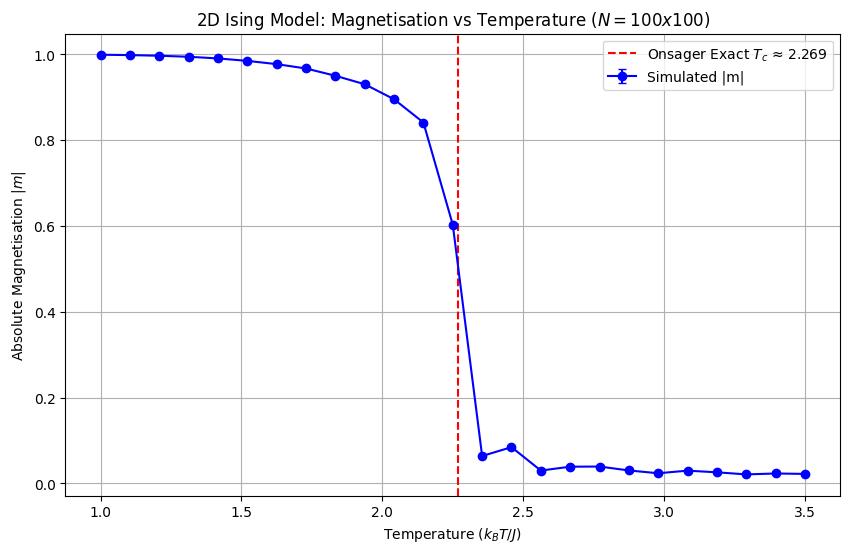

In [6]:
if __name__ == "__main__":
    # Simulation Parameters
    N = 100 # Grid size increased to 100x100
    sweeps = 500 # Number of sweeps to measure data
    equilibration_sweeps = 1000 # Increased for larger grid to ensure it settles

    # CRITICAL FIX: Simulated Annealing. (note to self, talk about this in my diseration)
    # Start HOT (3.5) and cool down to COLD (1.0) so the system doesn't get trapped in frozen domains
    temperatures = np.linspace(3.5, 1.0, 25)

    print("Running Monte Carlo Simulation. This may take a moment...")
    mean_mag, err_mag = run_simulation(N, temperatures, sweeps, equilibration_sweeps)

    # Onsager's Exact Benchmark (From Tong page 166 / Onsager 1944)
    Tc = 2.269

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.errorbar(temperatures, mean_mag, yerr=err_mag, fmt='o-', capsize=3, label='Simulated |m|', color='blue')
    plt.axvline(x=Tc, color='red', linestyle='--', label=f'Onsager Exact $T_c$ ≈ {Tc}')

    plt.title(f"2D Ising Model: Magnetisation vs Temperature ($N={N}x{N}$)")
    plt.xlabel("Temperature ($k_B T / J$)")
    plt.ylabel("Absolute Magnetisation $|m|$")
    plt.legend()
    plt.grid(True)
    plt.show()